# Hemodynamic Instability — Trajectory Exploration

This notebook begins the exploratory analysis for the `hemodynamic-instability` project.

Our initial goal is to understand how physiological signals evolve over time in ICU patients using the PhysioNet 2019 Challenge dataset.

We are not building prediction models yet.

Instead, we will:

- inspect patient trajectory structure
- visualize key physiological variables
- explore MAP behavior over time
- identify possible instability patterns
- evaluate whether simple instability definitions appear meaningful

The focus of this notebook is exploratory physiological dynamics analysis.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import (
    TRAINING_SET_A,
    TRAINING_SET_B,
    CORE_SIGNALS,
    MAP_THRESHOLD,
    savefig,
    savetable,
)

In [2]:
print("Training Set A path:", TRAINING_SET_A)
print("Training Set B path:", TRAINING_SET_B)

print("Training Set A exists:", TRAINING_SET_A.exists())
print("Training Set B exists:", TRAINING_SET_B.exists())

Training Set A path: /Users/suvo/Projects/hemodynamic-instability/data/raw/training_setA/training_setA
Training Set B path: /Users/suvo/Projects/hemodynamic-instability/data/raw/training_setB/training_setB
Training Set A exists: True
Training Set B exists: True


## Patient Files

Each `.psv` file represents one ICU patient trajectory.

We first inspect:
- number of patient files
- example filenames
- structure of a single patient file

In [3]:
files_A = sorted(TRAINING_SET_A.glob("*.psv"))
files_B = sorted(TRAINING_SET_B.glob("*.psv"))

all_files = files_A + files_B

print("Training Set A files:", len(files_A))
print("Training Set B files:", len(files_B))
print("Total patient files:", len(all_files))

print("\nExample files:")
for f in all_files[:5]:
    print(f.name)

Training Set A files: 20336
Training Set B files: 20000
Total patient files: 40336

Example files:
p000001.psv
p000002.psv
p000003.psv
p000004.psv
p000005.psv


In [4]:
df = pd.read_csv(all_files[0], sep="|")

print("Shape:", df.shape)

df.head()

Shape: (54, 41)


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0


## Initial Signal Inspection

Before visualizing trajectories, we inspect:
- available physiological variables
- missing values
- ICU stay duration
- basic MAP statistics

ICU physiological data is sparse and irregular, so understanding signal availability is important before defining instability events.

In [5]:
core_df = df[CORE_SIGNALS + ["ICULOS", "SepsisLabel"]]

core_df.head(10)

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,2,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,3,0
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,4,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,5,0
5,110.0,91.0,NaN,NaN,NaN,NaN,22.0,6,0
6,108.0,92.0,36.11,123.0,77.00,NaN,29.0,7,0
7,106.0,90.5,NaN,93.0,76.33,NaN,29.0,8,0
8,104.0,95.0,NaN,133.0,88.33,NaN,26.0,9,0
9,102.0,91.0,NaN,134.0,87.33,NaN,30.0,10,0


In [6]:
missing_summary = (
    core_df.isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

missing_summary = missing_summary.round(1)

missing_summary

DBP            100.0
Temp            81.5
SBP             22.2
MAP             22.2
O2Sat           18.5
HR               9.3
Resp             7.4
ICULOS           0.0
SepsisLabel      0.0
dtype: float64

In [7]:
print("Patient hours:", len(df))

print("\nMAP statistics:")
print(df["MAP"].describe())

print("\nHours with MAP < 65:")
print((df["MAP"] < MAP_THRESHOLD).sum())

Patient hours: 54

MAP statistics:
count     42.000000
mean      87.261905
std       21.270465
min       44.000000
25%       76.330000
50%       87.915000
75%       96.670000
max      141.330000
Name: MAP, dtype: float64

Hours with MAP < 65:
5


## Visualizing Patient Trajectories

We now inspect temporal physiological behavior across individual ICU patients.

The goal is exploratory:
- identify possible instability patterns
- observe MAP behavior over time
- examine whether other signals visibly change before low-MAP periods

At this stage, we are not building labels or prediction models.

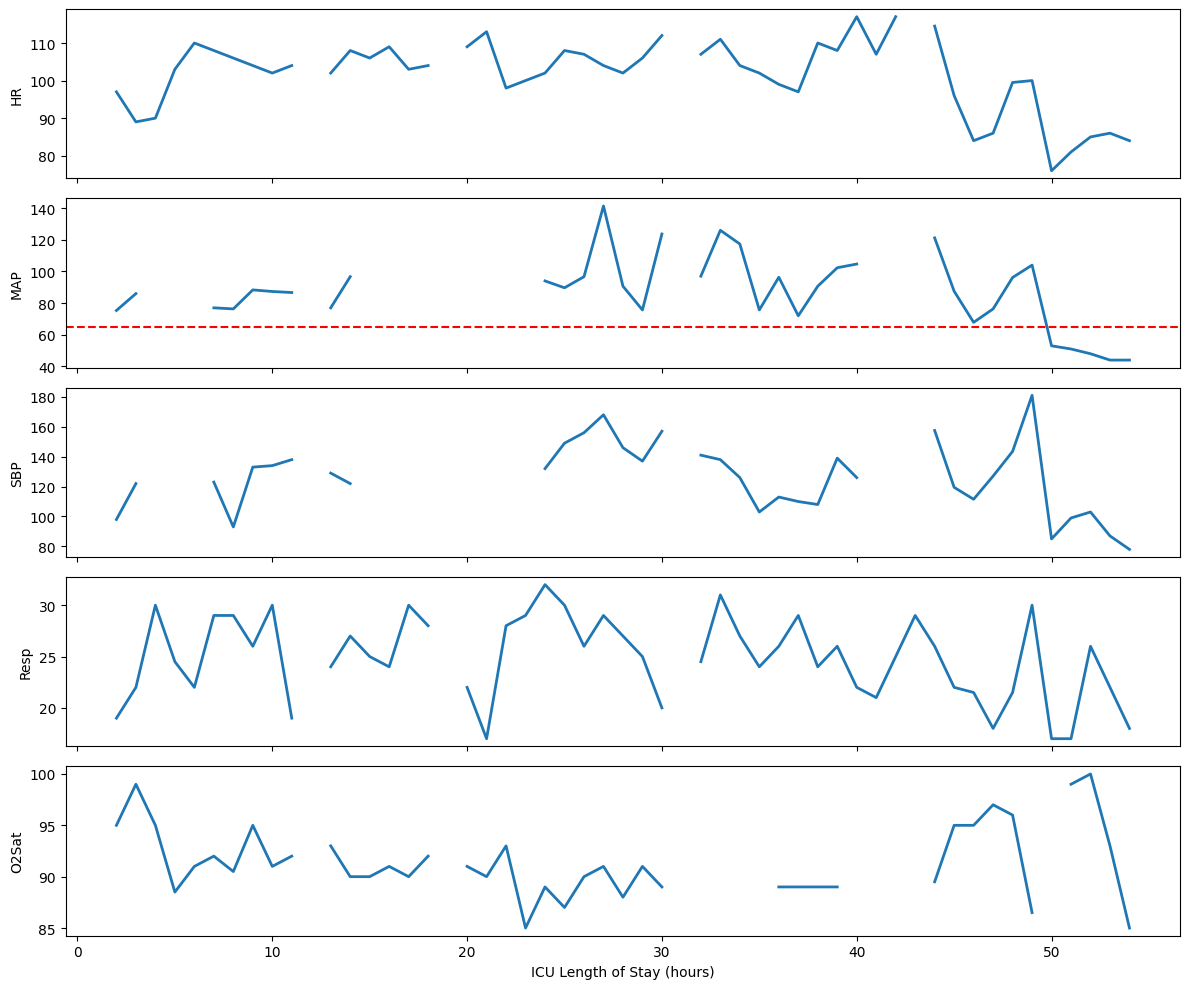

In [8]:
signals_to_plot = ["HR", "MAP", "SBP", "Resp", "O2Sat"]

fig, axes = plt.subplots(
    len(signals_to_plot),
    1,
    figsize=(12, 10),
    sharex=True
)

time = df["ICULOS"]

for ax, signal in zip(axes, signals_to_plot):

    ax.plot(time, df[signal], linewidth=2)

    if signal == "MAP":
        ax.axhline(
            MAP_THRESHOLD,
            color="red",
            linestyle="--",
            linewidth=1.5
        )

    ax.set_ylabel(signal)

axes[-1].set_xlabel("ICU Length of Stay (hours)")

plt.tight_layout()
plt.show()

## Exploring Multiple Patients

We now visualize MAP trajectories across multiple ICU patients.

The goal is to develop intuition for:
- instability frequency
- trajectory smoothness
- sustained low-MAP events
- variability across patients

At this stage, we are still exploring the physiology rather than defining final prediction labels.

In [9]:
candidate_files = []

for f in all_files[:500]:

    temp_df = pd.read_csv(f, sep="|")

    low_map_hours = (temp_df["MAP"] < MAP_THRESHOLD).sum()

    if low_map_hours >= 2:
        candidate_files.append(f)

print("Patients with at least 2 low-MAP hours:", len(candidate_files))

Patients with at least 2 low-MAP hours: 277


Saved figure: /Users/suvo/Projects/hemodynamic-instability/outputs/figures/multi_patient_map_trajectories.png


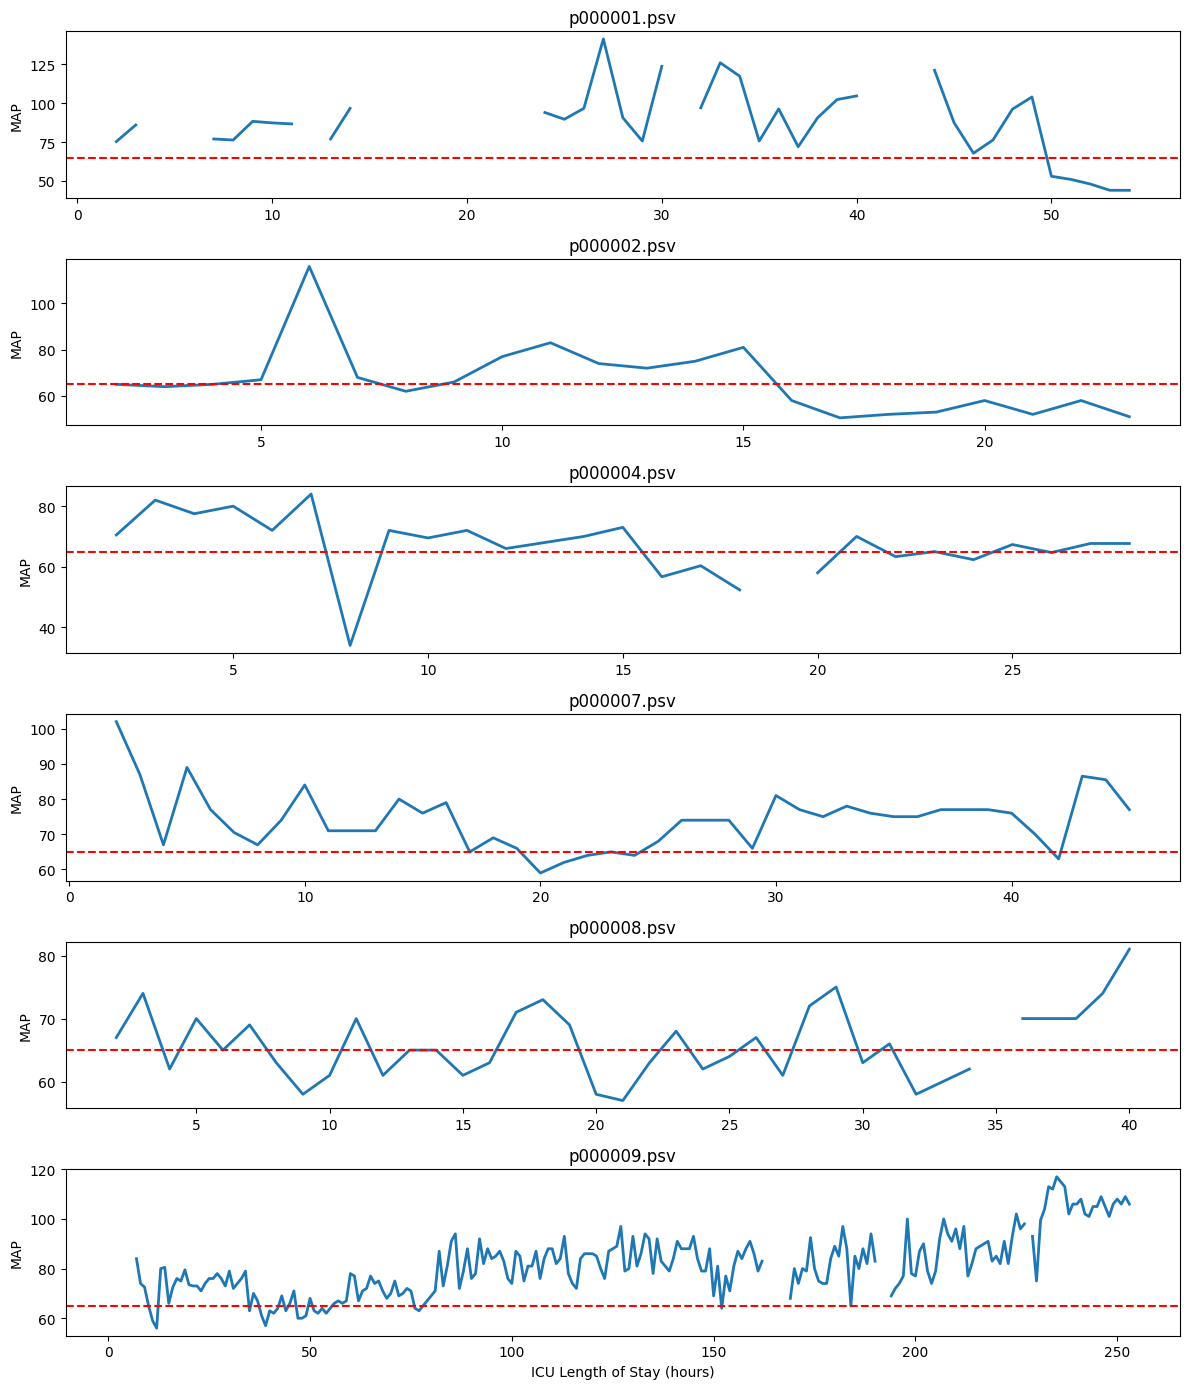

In [11]:
num_patients = 6

fig, axes = plt.subplots(
    num_patients,
    1,
    figsize=(12, 14),
    sharex=False
)

for ax, f in zip(axes, candidate_files[:num_patients]):

    temp_df = pd.read_csv(f, sep="|")

    ax.plot(
        temp_df["ICULOS"],
        temp_df["MAP"],
        linewidth=2
    )

    ax.axhline(
        MAP_THRESHOLD,
        color="red",
        linestyle="--",
        linewidth=1.5
    )

    ax.set_ylabel("MAP")

    ax.set_title(f.name)

axes[-1].set_xlabel("ICU Length of Stay (hours)")

plt.tight_layout()

savefig("multi_patient_map_trajectories.png")

plt.show()

## Patient-Level Instability Statistics

We now summarize hemodynamic behavior across a larger patient cohort.

For each patient, we compute exploratory instability metrics including:
- minimum MAP
- fraction of low-MAP hours
- longest sustained low-MAP episode
- MAP variability
- MAP range

The goal is to understand the overall instability landscape before defining prediction tasks.

In [12]:
def longest_low_map_run(map_series, threshold=65):
    """
    Compute longest consecutive run of MAP < threshold.
    """

    low = map_series < threshold

    max_run = 0
    current_run = 0

    for val in low:

        if val:
            current_run += 1
            max_run = max(max_run, current_run)

        else:
            current_run = 0

    return max_run

In [13]:
summary_rows = []

sample_files = all_files[:1000]

for f in sample_files:

    temp_df = pd.read_csv(f, sep="|")

    map_values = temp_df["MAP"].dropna()

    if len(map_values) == 0:
        continue

    row = {
        "patient": f.name,
        "hours": len(temp_df),
        "map_min": map_values.min(),
        "map_mean": map_values.mean(),
        "map_std": map_values.std(),
        "map_range": map_values.max() - map_values.min(),
        "low_map_fraction": (map_values < MAP_THRESHOLD).mean(),
        "longest_low_map_run": longest_low_map_run(map_values)
    }

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

summary_df.head()

,patient,hours,map_min,map_mean,map_std,map_range,low_map_fraction,longest_low_map_run
0,p000001.psv,54,44.00,87.261905,21.270465,97.33,0.119048,5
1,p000002.psv,23,50.50,66.704545,14.720134,65.50,0.454545,8
2,p000003.psv,48,62.67,81.048000,7.854301,36.33,0.022222,1
3,p000004.psv,29,34.00,67.147308,10.048494,50.00,0.307692,4
4,p000005.psv,48,73.00,87.088235,8.631764,30.00,0.000000,0


In [14]:
summary_df.describe().round(2)

,hours,map_min,map_mean,map_std,map_range,low_map_fraction,longest_low_map_run
count,999.00,999.00,999.00,998.00,999.00,999.00,999.00
mean,38.83,60.49,78.43,9.48,40.64,0.15,2.39
std,22.17,10.76,10.67,3.95,21.80,0.19,3.53
min,8.00,20.00,49.13,2.04,0.00,0.00,0.00
25%,24.00,54.00,70.91,7.05,28.00,0.00,0.00
50%,38.00,60.00,76.31,8.74,36.00,0.08,1.00
75%,48.00,66.84,84.87,11.08,48.00,0.22,3.00
max,258.00,98.50,118.28,54.15,236.00,1.00,45.00


Saved figure: /Users/suvo/Projects/hemodynamic-instability/outputs/figures/low_map_run_distribution.png


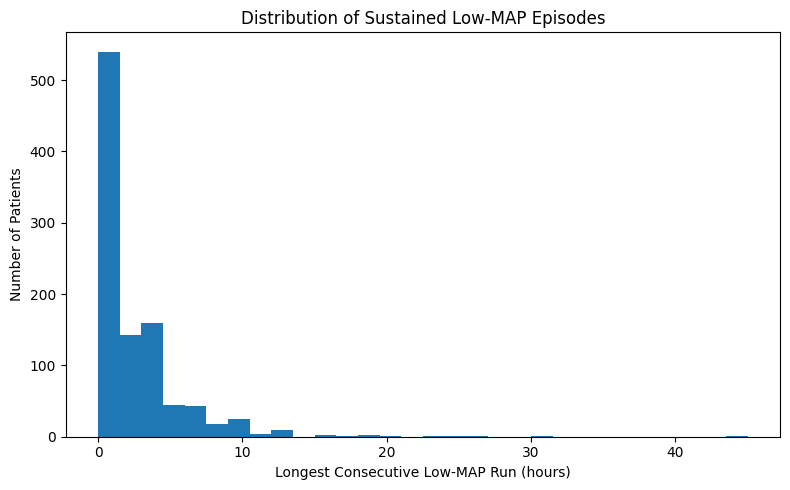

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    summary_df["longest_low_map_run"],
    bins=30
)

ax.set_xlabel("Longest Consecutive Low-MAP Run (hours)")
ax.set_ylabel("Number of Patients")
ax.set_title("Distribution of Sustained Low-MAP Episodes")

plt.tight_layout()

savefig("low_map_run_distribution.png")

plt.show()

Saved figure: /Users/suvo/Projects/hemodynamic-instability/outputs/figures/low_map_fraction_distribution.png


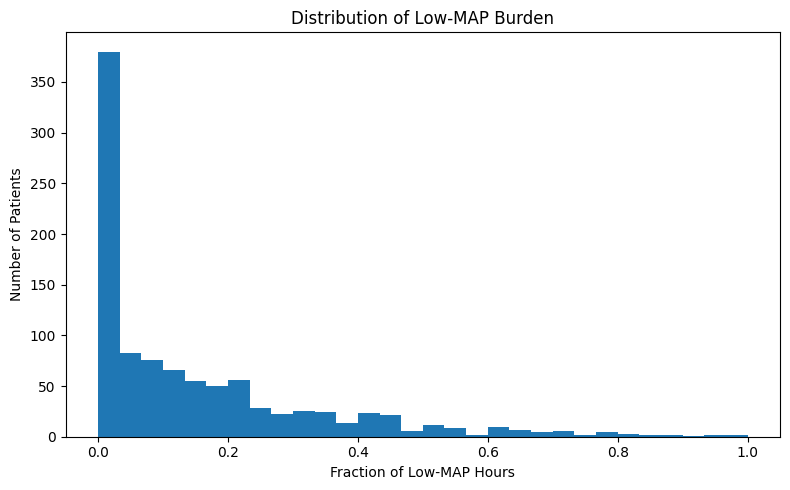

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    summary_df["low_map_fraction"],
    bins=30
)

ax.set_xlabel("Fraction of Low-MAP Hours")
ax.set_ylabel("Number of Patients")
ax.set_title("Distribution of Low-MAP Burden")

plt.tight_layout()

savefig("low_map_fraction_distribution.png")

plt.show()

Saved figure: /Users/suvo/Projects/hemodynamic-instability/outputs/figures/map_variability_vs_lowmap_burden.png


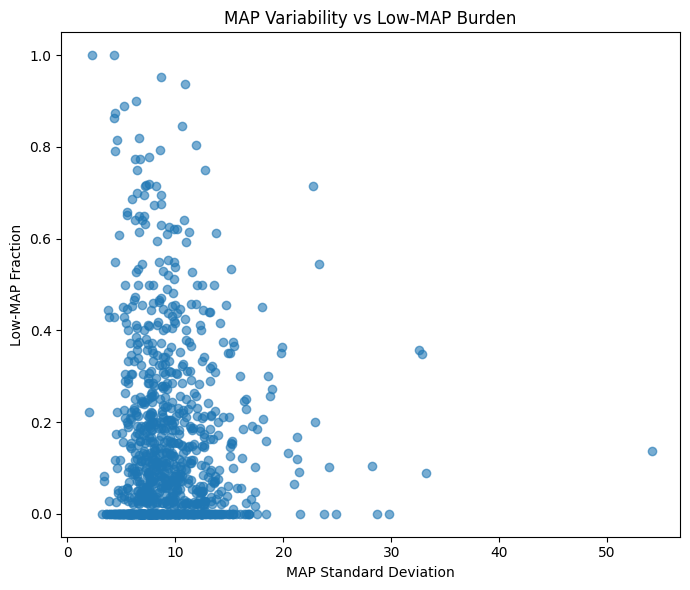

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))

scatter = ax.scatter(
    summary_df["map_std"],
    summary_df["low_map_fraction"],
    alpha=0.6
)

ax.set_xlabel("MAP Standard Deviation")
ax.set_ylabel("Low-MAP Fraction")
ax.set_title("MAP Variability vs Low-MAP Burden")

plt.tight_layout()

savefig("map_variability_vs_lowmap_burden.png")

plt.show()

## Instability Phenotyping

We now explore whether ICU patients naturally separate into different hemodynamic instability patterns.

Rather than treating instability as purely binary, we cluster patients using several physiologically interpretable MAP-based summary features:

- average MAP
- MAP variability
- low-MAP burden
- sustained low-MAP episodes
- MAP excursion range

The goal is exploratory:
- identify possible instability archetypes
- visualize the instability landscape
- determine whether distinct physiological behaviors emerge naturally

In [24]:
cluster_features = [
    "map_mean",
    "map_std",
    "low_map_fraction",
    "longest_low_map_run",
    "map_range",
]

cluster_df = (
    summary_df[cluster_features]
    .dropna()
    .copy()
)

print("Patients used for clustering:", len(cluster_df))

cluster_df.head()

Patients used for clustering: 998


,map_mean,map_std,low_map_fraction,longest_low_map_run,map_range
0,87.261905,21.270465,0.119048,5,97.33
1,66.704545,14.720134,0.454545,8,65.50
2,81.048000,7.854301,0.022222,1,36.33
3,67.147308,10.048494,0.307692,4,50.00
4,87.088235,8.631764,0.000000,0,30.00


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(cluster_df)

X_scaled.shape

(998, 5)

In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

cluster_df["cluster"] = clusters

cluster_df["cluster"].value_counts().sort_index()

cluster
0    276
1    183
2    520
3     19
Name: count, dtype: int64

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

cluster_df["pca1"] = X_pca[:, 0]
cluster_df["pca2"] = X_pca[:, 1]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.50394894 0.36913561]


Saved figure: /Users/suvo/Projects/hemodynamic-instability/outputs/figures/hemodynamic_instability_clusters_with_legend.png


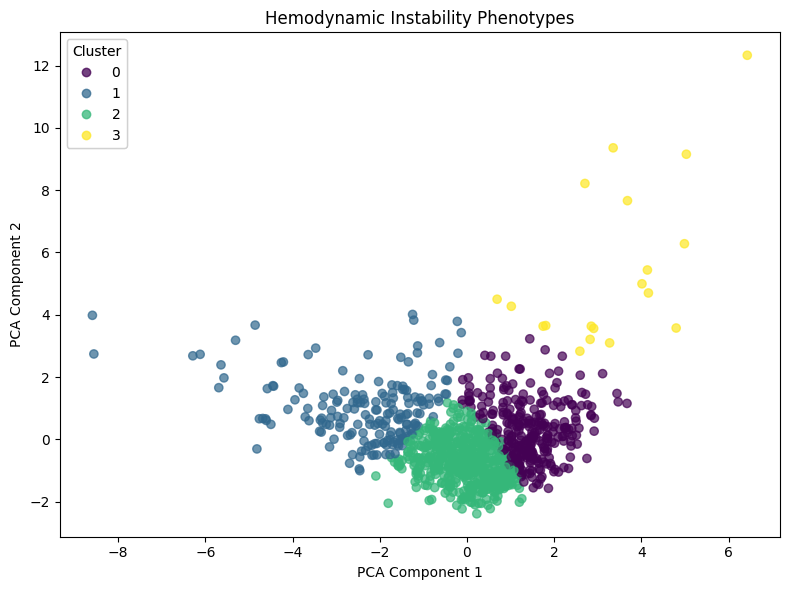

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    cluster_df["pca1"],
    cluster_df["pca2"],
    c=cluster_df["cluster"],
    alpha=0.7
)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")

ax.set_title("Hemodynamic Instability Phenotypes")

legend = ax.legend(
    *scatter.legend_elements(),
    title="Cluster"
)

ax.add_artist(legend)

plt.tight_layout()

savefig("hemodynamic_instability_clusters_with_legend.png")

plt.show()

In [31]:
cluster_summary = (
    cluster_df
    .groupby("cluster")[cluster_features]
    .mean()
    .round(2)
)

cluster_summary

,map_mean,map_std,low_map_fraction,longest_low_map_run,map_range
cluster,,,,,
0,89.71,11.97,0.04,0.86,51.76
1,66.24,9.12,0.48,7.60,38.43
2,76.33,7.67,0.10,1.39,31.79
3,89.82,25.95,0.12,2.05,144.94


## Representative Hemodynamic Phenotypes

To better understand the discovered instability clusters, we now visualize representative MAP trajectories from each phenotype.

The goal is to connect the abstract clustering structure back to real physiological behavior.

We specifically examine whether the clusters correspond to:
- stable physiology
- oscillatory instability
- chronic hypotension
- extreme excursion behavior

In [33]:
cluster_df = summary_df.dropna().copy()

cluster_df = cluster_df.reset_index(drop=True)

cluster_df["cluster"] = clusters

cluster_df.head()

,patient,hours,map_min,map_mean,map_std,map_range,low_map_fraction,longest_low_map_run,cluster
0,p000001.psv,54,44.00,87.261905,21.270465,97.33,0.119048,5,3
1,p000002.psv,23,50.50,66.704545,14.720134,65.50,0.454545,8,1
2,p000003.psv,48,62.67,81.048000,7.854301,36.33,0.022222,1,2
3,p000004.psv,29,34.00,67.147308,10.048494,50.00,0.307692,4,1
4,p000005.psv,48,73.00,87.088235,8.631764,30.00,0.000000,0,2


In [34]:
from scipy.spatial.distance import cdist

distances = cdist(
    X_scaled,
    kmeans.cluster_centers_
)

representative_indices = []

for cluster_id in range(kmeans.n_clusters):

    cluster_member_indices = np.where(clusters == cluster_id)[0]

    cluster_distances = distances[
        cluster_member_indices,
        cluster_id
    ]

    nearest_idx = cluster_member_indices[
        np.argmin(cluster_distances)
    ]

    representative_indices.append(nearest_idx)

representative_indices

[np.int64(599), np.int64(804), np.int64(711), np.int64(18)]

In [35]:
representatives = cluster_df.iloc[
    representative_indices
]

representatives[
    ["patient", "cluster"] + cluster_features
]

,patient,cluster,map_mean,map_std,low_map_fraction,longest_low_map_run,map_range
599,p000602.psv,0,89.950000,12.610459,0.050000,1,50.0
804,p000807.psv,1,65.500000,9.289535,0.521739,8,34.0
711,p000714.psv,2,75.200000,7.918001,0.100000,1,29.0
18,p000019.psv,3,92.308511,23.756361,0.000000,0,154.0


In [40]:
phenotype_names = {
    0: "Oscillatory Instability",
    1: "Chronic Hypotensive Fragility",
    2: "Stable Hemodynamics",
    3: "Extreme Excursion Dynamics",
}

Saved figure: /Users/suvo/Projects/hemodynamic-instability/outputs/figures/representative_hemodynamic_phenotypes_named.png


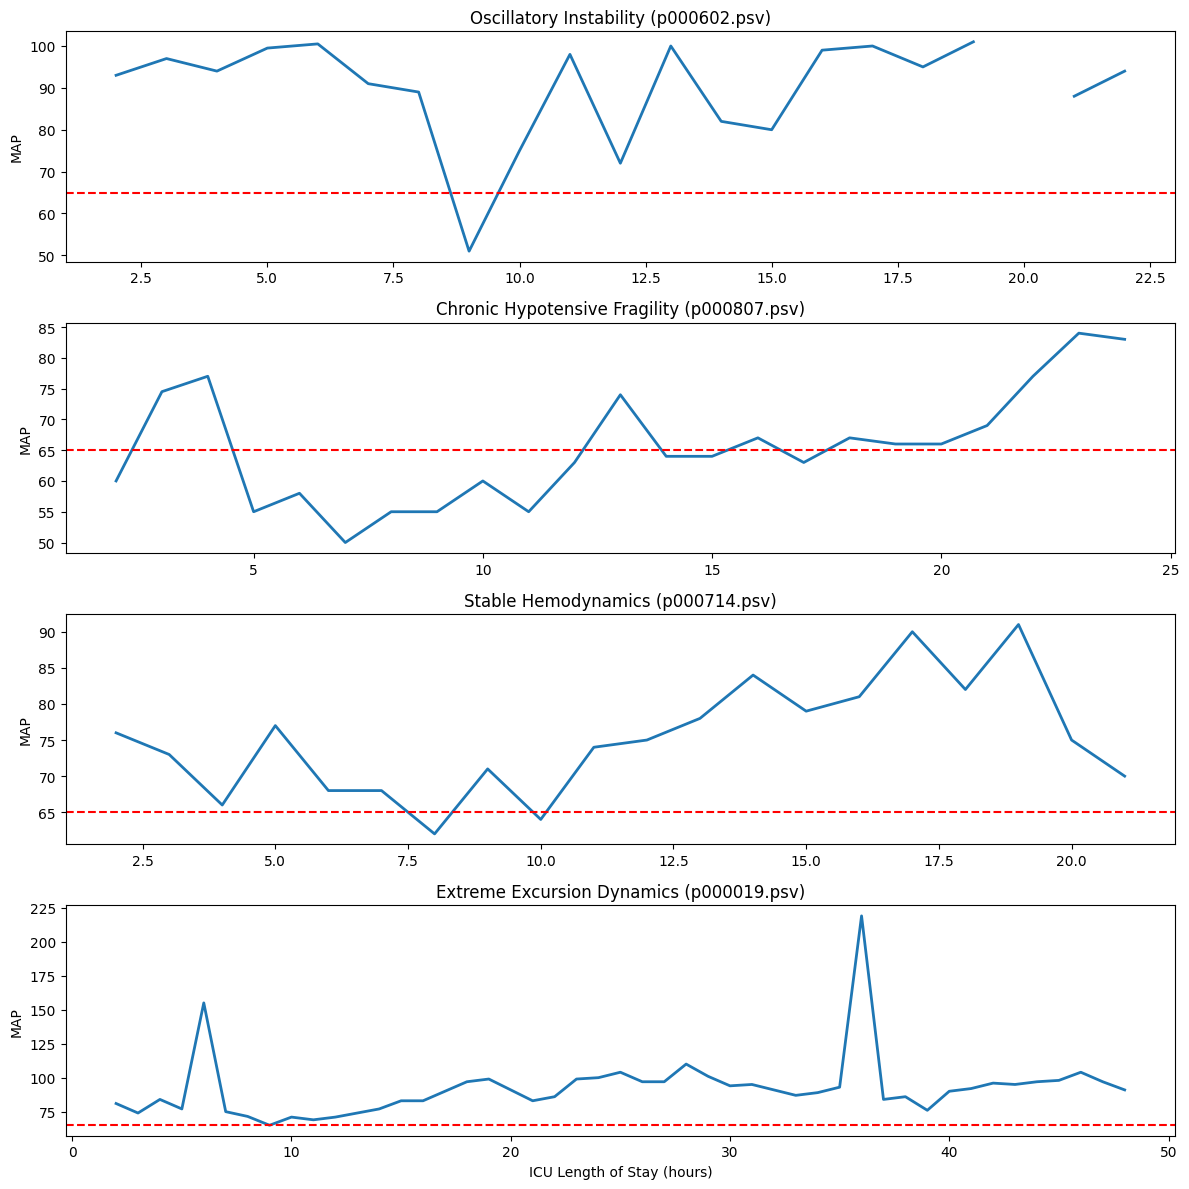

In [41]:
fig, axes = plt.subplots(
    kmeans.n_clusters,
    1,
    figsize=(12, 12),
    sharex=False
)

for ax, (_, row) in zip(axes, representatives.iterrows()):

    patient_file = TRAINING_SET_A / row["patient"]

    if not patient_file.exists():
        patient_file = TRAINING_SET_B / row["patient"]

    temp_df = pd.read_csv(patient_file, sep="|")

    ax.plot(
        temp_df["ICULOS"],
        temp_df["MAP"],
        linewidth=2
    )

    ax.axhline(
        MAP_THRESHOLD,
        color="red",
        linestyle="--",
        linewidth=1.5
    )

    cluster_id = int(row["cluster"])

    phenotype = phenotype_names[cluster_id]

    ax.set_ylabel("MAP")

    ax.set_title(
        f"{phenotype} ({row['patient']})"
    )

axes[-1].set_xlabel("ICU Length of Stay (hours)")

plt.tight_layout()

savefig("representative_hemodynamic_phenotypes_named.png")

plt.show()

## Broader Physiological Differences Across Phenotypes

The clusters were created using only MAP-based instability features.

We now ask whether these MAP-derived phenotypes also differ in other physiological signals, such as heart rate, respiration, oxygen saturation, and temperature.

This helps determine whether the clusters represent broader physiological states rather than MAP-only artifacts.

In [37]:
extra_signals = ["HR", "Resp", "O2Sat", "Temp"]

extra_rows = []

for patient in cluster_df["patient"]:

    patient_file = TRAINING_SET_A / patient

    if not patient_file.exists():
        patient_file = TRAINING_SET_B / patient

    temp_df = pd.read_csv(patient_file, sep="|")

    row = {"patient": patient}

    for signal in extra_signals:

        values = temp_df[signal].dropna()

        if len(values) == 0:
            row[f"{signal}_mean"] = np.nan
            row[f"{signal}_std"] = np.nan
        else:
            row[f"{signal}_mean"] = values.mean()
            row[f"{signal}_std"] = values.std()

    row["max_sepsis_label"] = temp_df["SepsisLabel"].max()
    row["iculos_hours"] = temp_df["ICULOS"].max()

    extra_rows.append(row)

extra_summary_df = pd.DataFrame(extra_rows)

extra_summary_df.head()

,patient,HR_mean,HR_std,Resp_mean,Resp_std,O2Sat_mean,O2Sat_std,Temp_mean,Temp_std,max_sepsis_label,iculos_hours
0,p000001.psv,101.571429,9.594378,24.820000,4.106689,91.477273,3.460667,36.778000,0.421078,0,54
1,p000002.psv,60.954545,8.144395,14.236842,4.667763,97.000000,2.138090,36.165000,0.151625,0,23
2,p000003.psv,79.611111,6.714036,25.633333,4.247192,95.431818,1.655122,37.609375,0.565597,0,48
3,p000004.psv,102.444444,6.337212,18.884615,3.742480,98.203704,1.449531,36.455000,0.262507,0,29
4,p000005.psv,73.916667,7.586697,16.500000,1.788854,97.500000,0.741620,36.992222,0.423520,0,49


In [38]:
cluster_phys_df = cluster_df.merge(
    extra_summary_df,
    on="patient",
    how="left"
)

cluster_phys_df.head()

,patient,hours,map_min,map_mean,map_std,map_range,low_map_fraction,longest_low_map_run,cluster,HR_mean,HR_std,Resp_mean,Resp_std,O2Sat_mean,O2Sat_std,Temp_mean,Temp_std,max_sepsis_label,iculos_hours
0,p000001.psv,54,44.00,87.261905,21.270465,97.33,0.119048,5,3,101.571429,9.594378,24.820000,4.106689,91.477273,3.460667,36.778000,0.421078,0,54
1,p000002.psv,23,50.50,66.704545,14.720134,65.50,0.454545,8,1,60.954545,8.144395,14.236842,4.667763,97.000000,2.138090,36.165000,0.151625,0,23
2,p000003.psv,48,62.67,81.048000,7.854301,36.33,0.022222,1,2,79.611111,6.714036,25.633333,4.247192,95.431818,1.655122,37.609375,0.565597,0,48
3,p000004.psv,29,34.00,67.147308,10.048494,50.00,0.307692,4,1,102.444444,6.337212,18.884615,3.742480,98.203704,1.449531,36.455000,0.262507,0,29
4,p000005.psv,48,73.00,87.088235,8.631764,30.00,0.000000,0,2,73.916667,7.586697,16.500000,1.788854,97.500000,0.741620,36.992222,0.423520,0,49


In [39]:
physiology_features = [
    "HR_mean",
    "HR_std",
    "Resp_mean",
    "Resp_std",
    "O2Sat_mean",
    "O2Sat_std",
    "Temp_mean",
    "Temp_std",
    "max_sepsis_label",
    "iculos_hours",
]

cluster_physiology_summary = (
    cluster_phys_df
    .groupby("cluster")[physiology_features]
    .mean()
    .round(2)
)

cluster_physiology_summary

,HR_mean,HR_std,Resp_mean,Resp_std,O2Sat_mean,O2Sat_std,Temp_mean,Temp_std,max_sepsis_label,iculos_hours
cluster,,,,,,,,,,
0,85.56,8.96,18.72,3.70,97.29,1.87,36.94,0.48,0.09,44.28
1,83.09,8.32,19.00,3.78,96.97,2.06,36.89,0.55,0.12,41.27
2,84.38,7.89,18.46,3.61,97.13,1.87,36.89,0.49,0.08,36.56
3,85.61,9.78,17.97,4.14,97.44,2.75,36.84,0.56,0.00,46.47


## 10. Phenotype Feature Profile

We now summarize the discovered hemodynamic phenotypes using a normalized feature profile.

Because the MAP-derived features have different units and scales, we normalize each feature across clusters before visualization.

This figure helps show which physiological characteristics define each phenotype.

In [42]:
cluster_summary_named = cluster_summary.copy()

cluster_summary_named["phenotype"] = cluster_summary_named.index.map(phenotype_names)

cluster_summary_named = cluster_summary_named.set_index("phenotype")

cluster_summary_named

,map_mean,map_std,low_map_fraction,longest_low_map_run,map_range
phenotype,,,,,
Oscillatory Instability,89.71,11.97,0.04,0.86,51.76
Chronic Hypotensive Fragility,66.24,9.12,0.48,7.60,38.43
Stable Hemodynamics,76.33,7.67,0.10,1.39,31.79
Extreme Excursion Dynamics,89.82,25.95,0.12,2.05,144.94


Saved figure: /Users/suvo/Projects/hemodynamic-instability/outputs/figures/hemodynamic_phenotype_feature_profile.png


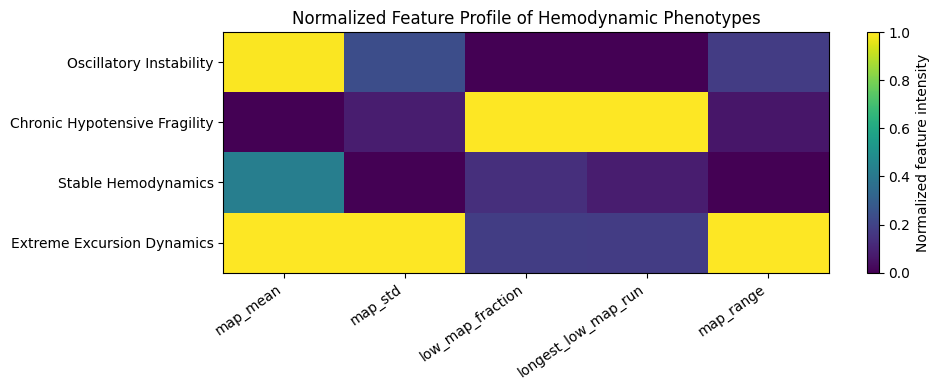

In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

profile_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_summary_named),
    index=cluster_summary_named.index,
    columns=cluster_summary_named.columns
)

fig, ax = plt.subplots(figsize=(10, 4))

im = ax.imshow(profile_scaled, aspect="auto")

ax.set_xticks(np.arange(len(profile_scaled.columns)))
ax.set_yticks(np.arange(len(profile_scaled.index)))

ax.set_xticklabels(profile_scaled.columns, rotation=35, ha="right")
ax.set_yticklabels(profile_scaled.index)

ax.set_title("Normalized Feature Profile of Hemodynamic Phenotypes")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Normalized feature intensity")

plt.tight_layout()

savefig("hemodynamic_phenotype_feature_profile.png")

plt.show()